# MovieLens 32M: Exploratory Data Analysis

**Phase 1: evidence before pipeline design.** Before building the data pipeline, I want to understand what is in the MovieLens files, whether the records are usable, and what happens when we split them chronologically. This notebook walks through those questions and uses the findings to recommend the next steps.

The analysis covers the full dataset in small batches. The raw files stay unchanged, and this notebook does not train a model or write final train/validation/test files. The split options are experiments to help choose an evaluation approach, not a finalized protocol.

**How to use this notebook**

1. Open it from this repository and select a Python 3.11+ kernel.
2. Make sure `pandas`, `numpy`, `matplotlib`, and `ipykernel` are installed in that kernel's environment. If needed, run `%pip install pandas numpy matplotlib ipykernel` in a separate cell.
3. Keep the four MovieLens CSV files together in `data/`, `data/raw/`, or `trustworthy_recsys/data/`. The setup cell checks those locations in that order and prints the one it selects. The root-level `README.txt` and `checksums.txt` are also required.
4. Run the cells from top to bottom. Later sections depend on the counts and metadata created earlier, so allow several minutes for the full scans to finish.
5. Read each table alongside the explanation above it. The saved outputs are already available if you only want to review the findings.

**Sources used here:** the local MovieLens CSV files, their `checksums.txt` manifest, and the dataset `README.txt`. That documentation identifies the release as `ml-32m`, generated October 13, 2023. The analysis itself does not download external data.

## Findings at a glance

Here are the main findings to keep in mind as you go through the notebook. The detailed checks and calculations follow in the numbered sections.

| Question | What the analysis shows |
|---|---|
| Do the files match the supplied manifest? | All four checksums match. This confirms consistency with the local manifest. |
| Are there obvious structural problems in the ratings? | Across 32,000,204 rows, there are no missing fields, invalid star values, broken movie references, or repeated user-movie pairs. |
| Does every catalog movie have ratings? | No. There are 84,432 rated movies out of 87,585 catalog movies, leaving 3,153 without ratings. |
| Is activity spread evenly across movies? | The top 1% of rated movies receive 54.9% of ratings, while the median rated movie has only 5 ratings. |
| Can we depend on optional metadata? | Only 58.6% of catalog movies have tags, and 7,080 movies have no listed genres. |
| What happens with a chronological 80/10/10 split? | The boundaries fall on 2018-10-04 and 2020-11-06. Only 9.79% of test events involve both a user and a movie seen in training. |
| Does 70/20/10 improve that coverage? | With the same test events, coverage falls to 5.82% when measured against training only. Section 6b explains the tradeoff. |
| Can these files support logged-propensity evaluation on their own? | No. They contain neither exposure probabilities nor impression logs. |

The main decision before implementation is **what the evaluation should represent**: serving everyone who arrives later, including new users and movies, or ranking for users with an established history. That choice determines how cold-start cases should be handled; the split ratio alone cannot answer it.

In [1]:
# If dependencies are missing, run %pip install pandas numpy matplotlib ipykernel in a separate cell.
%matplotlib inline
from pathlib import Path
from collections import Counter
import hashlib
import platform
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
FILENAMES = ['ratings.csv', 'movies.csv', 'tags.csv', 'links.csv']
CANDIDATES = [ROOT / 'data', ROOT / 'data/raw', ROOT / 'trustworthy_recsys/data']
DATA_DIR = next((p for p in CANDIDATES if all((p / f).is_file() for f in FILENAMES)), None)
assert DATA_DIR is not None, 'Place the four MovieLens CSV files together in one of CANDIDATES.'
CHUNK_SIZE = 50_000
print('Data directory:', DATA_DIR.relative_to(ROOT))
print('Python:', platform.python_version())
print('Versions:', {m.__name__: m.__version__ for m in [pd, np, matplotlib]})
print('Batch size:', f'{CHUNK_SIZE:,}')

Data directory: trustworthy_recsys\data
Python: 3.14.6
Versions: {'pandas': '2.3.3', 'numpy': '2.3.4', 'matplotlib': '3.10.8'}
Batch size: 50,000


## 1. Source inventory and integrity

Start by checking that the four files match the MD5 checksums supplied with the dataset. The table below shows each file's size, calculated checksum, and whether it matches the manifest. The assertion stops the notebook if a file differs, so a changed or incomplete source is not silently carried into the analysis.

A matching checksum establishes consistency with the bundled manifest. It does not independently establish where the download came from. For reference, the dataset documentation reports **32,000,204 ratings, 2,000,072 tag applications, 87,585 movies, and 200,948 rating users**. Later sections compare those totals with the actual records.

The small previews help explain the columns before the full scans begin; the analysis itself is not limited to these preview rows.

In [2]:
manifest = {}
for line in (ROOT / 'checksums.txt').read_text().splitlines():
    digest, name = line.split()
    manifest[name.lstrip('*')] = digest
inventory = []
for name in FILENAMES:
    path = DATA_DIR / name
    digest = hashlib.md5()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    inventory.append({'file': name, 'MiB': round(path.stat().st_size / 2**20, 2),
                      'md5': digest.hexdigest(), 'matches_manifest': digest.hexdigest() == manifest[name]})
display(pd.DataFrame(inventory))
assert all(row['matches_manifest'] for row in inventory), 'Source file differs from bundled manifest.'
for name in FILENAMES:
    print(name)
    display(pd.read_csv(DATA_DIR / name, nrows=3))

,file,MiB,md5,matches_manifest
0,ratings.csv,836.45,cf12b74f9ad4b94a011f079e26d4270a,True
1,movies.csv,4.05,0df90835c19151f9d819d0822e190797,True
2,tags.csv,69.00,963bf4fa4de6b8901868fddd3eb54567,True
3,links.csv,1.86,8f033867bcb4e6be8792b21468b4fa6e,True


ratings.csv


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976


movies.csv


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


tags.csv


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469


links.csv


,movieId,imdbId,tmdbId
0,1,114709,862
1,2,113497,8844
2,3,113228,15602


## 2. Movie metadata and identifier quality

Movie IDs connect all four tables, while user IDs connect ratings and tags. Before relying on those joins, check that the movie identifiers are unique and that the movie and links tables cover the same IDs. The next cell reports missing values, duplicate rows, duplicate IDs, blank titles, and missing genres. IMDb IDs are read as strings so leading zeroes are preserved. Repeated titles are reported separately: two records with the same title are not automatically the same movie. Release years are extracted from the final parenthesized year in each title. Treat this as a convenient description of the catalog, not a verified release-date field. A title without a parseable year should not be removed just because that extraction fails.

In [3]:
movies = pd.read_csv(DATA_DIR / 'movies.csv', dtype={'movieId': 'int32'})
links = pd.read_csv(DATA_DIR / 'links.csv', dtype={'movieId': 'int32', 'imdbId': 'string', 'tmdbId': 'string'})
metadata_quality = []
for name, frame in [('movies', movies), ('links', links)]:
    metadata_quality.append({'table': name, 'rows': len(frame), 'duplicate_movie_ids': int(frame.movieId.duplicated().sum()),
                             'duplicate_rows': int(frame.duplicated().sum()),
                             'nonpositive_movie_ids': int(frame.movieId.le(0).sum())})
    display(frame.isna().sum().rename(name + '_missing').to_frame())
display(pd.DataFrame(metadata_quality))
print('Movie IDs absent from links:', len(set(movies.movieId) - set(links.movieId)))
print('Link IDs absent from movies:', len(set(links.movieId) - set(movies.movieId)))
print('Missing/blank titles:', int((movies.title.isna() | movies.title.fillna('').str.strip().eq('')).sum()))
print('Movies without listed genres:', int(movies.genres.fillna('(no genres listed)').eq('(no genres listed)').sum()))
print('Repeated title strings (not necessarily duplicate movies):', int(movies.title.duplicated().sum()))
release_year = pd.to_numeric(movies.title.str.extract(r'\((\d{4})\)\s*$', expand=False), errors='coerce')
print('Titles without a parseable final release year:', int(release_year.isna().sum()))
genres = movies.assign(genre=movies.genres.fillna('(no genres listed)').str.split('|')).explode('genre')
display(genres.genre.value_counts().rename('catalog_movies').to_frame())

,movies_missing
movieId,0
title,0
genres,0


,links_missing
movieId,0
imdbId,0
tmdbId,124


,table,rows,duplicate_movie_ids,duplicate_rows,nonpositive_movie_ids
0,movies,87585,0,0,0
1,links,87585,0,0,0


Movie IDs absent from links: 0
Link IDs absent from movies: 0
Missing/blank titles: 0
Movies without listed genres: 7080
Repeated title strings (not necessarily duplicate movies): 203


Titles without a parseable final release year: 617


,catalog_movies
genre,
Drama,34175
Comedy,23124
Thriller,11823
Romance,10369
Action,9668
Documentary,9363
Horror,8654
(no genres listed),7080
Crime,6976


## 3. Full ratings audit and compact aggregates

This is the first full pass through the ratings file. It checks required numeric fields, allowed half-star ratings, movie references, and timestamp validity. To keep memory use manageable, the scan retains counts and first/last interaction times per user and movie instead of loading all 32 million rows at once. The source documentation says records are ordered by user ID and then movie ID. That order is checked both within batches and across their boundaries. Once verified, repeated adjacent user-movie keys give an exact count of repeated pairs. If ordering fails, stop and use a global duplicate check before trusting the duplicate total.

Parsing failures and missing required fields stop the scan rather than silently remove rows. Other audit counts appear in the output table. Pay particular attention to the timestamp boundary check: a rating on the release date is something to investigate, not automatically an invalid record. The final summary reports the observed dataset size, date range, average rating, and user-catalog density. Density is the fraction of all possible user-movie pairs represented by a rating; it helps explain how sparse the recommendation problem is.

In [4]:
# Resize the count arrays as larger IDs appear, avoiding a full in-memory ratings table.
INF = np.iinfo(np.int64).max
user_count = np.zeros(1, dtype=np.int64)
item_count = np.zeros(int(movies.movieId.max()) + 1, dtype=np.int64)
user_first = np.full(1, INF, dtype=np.int64)
user_last = np.zeros(1, dtype=np.int64)
item_first = np.full(len(item_count), INF, dtype=np.int64)
item_rating_sum = np.zeros(len(item_count), dtype=np.float64)
known_movies = np.zeros(len(item_count), dtype=bool)
known_movies[movies.movieId.to_numpy()] = True
rating_hist, daily_hist, monthly_hist = Counter(), Counter(), Counter()
quality = Counter()
total_ratings = 0
previous_key = None
ordering_ok = True
min_timestamp, max_timestamp = INF, 0
rating_columns = ['userId', 'movieId', 'rating', 'timestamp']

def expand(array, size, fill=0):
    if size <= len(array):
        return array
    return np.pad(array, (0, size - len(array)), constant_values=fill)

for batch_number, chunk in enumerate(pd.read_csv(DATA_DIR / 'ratings.csv', chunksize=CHUNK_SIZE), 1):
    assert list(chunk.columns) == rating_columns
    quality['missing_cells'] += int(chunk.isna().sum().sum())
    assert not chunk.isna().any().any(), 'Missing required rating fields: inspect before aggregating.'
    for col in ['userId', 'movieId', 'timestamp']:
        assert pd.api.types.is_numeric_dtype(chunk[col]) and chunk[col].mod(1).eq(0).all(), f'Invalid {col}'
    u = chunk.userId.to_numpy(dtype=np.int64)
    i = chunk.movieId.to_numpy(dtype=np.int64)
    t = chunk.timestamp.to_numpy(dtype=np.int64)
    r = chunk.rating.to_numpy(dtype=np.float64)
    assert (u > 0).all() and (i > 0).all(), 'Nonpositive IDs need investigation.'
    quality['invalid_ratings'] += int((~np.isin(r, np.arange(0.5, 5.1, 0.5))).sum())
    dates = pd.to_datetime(t, unit='s', utc=True, errors='coerce')
    quality['invalid_timestamps'] += int(dates.isna().sum())
    quality['timestamps_before_1995'] += int((t < 788918400).sum())
    quality['timestamps_on_or_after_release'] += int((t >= 1697155200).sum())
    user_count = expand(user_count, int(u.max()) + 1)
    user_first = expand(user_first, len(user_count), INF)
    user_last = expand(user_last, len(user_count))
    item_count = expand(item_count, int(i.max()) + 1)
    item_first = expand(item_first, len(item_count), INF)
    item_rating_sum = expand(item_rating_sum, len(item_count))
    known_movies = expand(known_movies, len(item_count), False)
    quality['unknown_movie_rows'] += int((~known_movies[i]).sum())
    np.add.at(user_count, u, 1)
    np.add.at(item_count, i, 1)
    np.add.at(item_rating_sum, i, r)
    np.minimum.at(user_first, u, t)
    np.maximum.at(user_last, u, t)
    np.minimum.at(item_first, i, t)
    # Compare user/movie keys in order without assuming a fixed ID bit width.
    repeated = (u[1:] == u[:-1]) & (i[1:] == i[:-1])
    descents = (u[1:] < u[:-1]) | ((u[1:] == u[:-1]) & (i[1:] < i[:-1]))
    quality['adjacent_repeated_user_movie_pairs'] += int(repeated.sum())
    quality['adjacent_identical_rows'] += int((repeated & (t[1:] == t[:-1]) & (r[1:] == r[:-1])).sum())
    ordering_ok = ordering_ok and not bool(descents.any())
    if previous_key is not None:
        old_u, old_i, old_t, old_r = previous_key
        ordering_ok = ordering_ok and (int(u[0]), int(i[0])) >= (old_u, old_i)
        same_pair = (int(u[0]), int(i[0])) == (old_u, old_i)
        quality['adjacent_repeated_user_movie_pairs'] += int(same_pair)
        quality['adjacent_identical_rows'] += int(same_pair and t[0] == old_t and r[0] == old_r)
    previous_key = (int(u[-1]), int(i[-1]), int(t[-1]), float(r[-1]))
    rating_hist.update(chunk.rating.value_counts().to_dict())
    days, counts = np.unique(t // 86400, return_counts=True)
    daily_hist.update(dict(zip(days.tolist(), counts.tolist())))
    # Count numeric months first; formatting only distinct months keeps the scan fast.
    months, counts = np.unique(t.astype('datetime64[s]').astype('datetime64[M]').astype(np.int64), return_counts=True)
    monthly_hist.update({str(np.datetime64(int(month), 'M')): int(count) for month, count in zip(months, counts)})
    min_timestamp = min(min_timestamp, int(t.min()))
    max_timestamp = max(max_timestamp, int(t.max()))
    total_ratings += len(chunk)
    if batch_number % 160 == 0:
        print(f'Scanned {total_ratings:,} ratings')

assert ordering_ok, 'Unsorted source: use a global duplicate audit before interpreting pair counts.'
active_users = np.flatnonzero(user_count)
active_items = np.flatnonzero(item_count)
assert user_count.sum() == item_count.sum() == total_ratings
print('Verified global user/movie ordering:', ordering_ok)
display(pd.Series(quality, name='count').to_frame())
summary = pd.Series({'ratings': total_ratings, 'rating_users': len(active_users),
                     'rated_movies': len(active_items), 'catalog_movies': len(movies),
                     'catalog_movies_without_ratings': int((item_count[movies.movieId] == 0).sum()),
                     'earliest_rating_UTC': str(pd.to_datetime(min_timestamp, unit='s', utc=True)),
                     'latest_rating_UTC': str(pd.to_datetime(max_timestamp, unit='s', utc=True)),
                     'mean_rating': sum(k*v for k,v in rating_hist.items()) / total_ratings,
                     'user_catalog_density_pct': 100 * total_ratings / (len(active_users) * len(movies))})
display(summary.to_frame('observed'))
print('Matches documented rating/user/movie counts:',
      (total_ratings, len(active_users), len(movies)) == (32_000_204, 200_948, 87_585))

Scanned 8,000,000 ratings


Scanned 16,000,000 ratings


Scanned 24,000,000 ratings


Scanned 32,000,000 ratings
Verified global user/movie ordering: True


,count
missing_cells,0
invalid_ratings,0
invalid_timestamps,0
timestamps_before_1995,0
timestamps_on_or_after_release,108
unknown_movie_rows,0
adjacent_repeated_user_movie_pairs,0
adjacent_identical_rows,0


,observed
ratings,32000204
rating_users,200948
rated_movies,84432
catalog_movies,87585
catalog_movies_without_ratings,3153
earliest_rating_UTC,1995-01-09 11:46:44+00:00
latest_rating_UTC,2023-10-13 02:29:07+00:00
mean_rating,3.540396
user_catalog_density_pct,0.181819


Matches documented rating/user/movie counts: True


## 4. User history, popularity, ratings and time

Now that the ratings have been checked, the next question is how activity is distributed. Look at the median as well as the average: a small number of very active users or very popular movies can pull the average upward. The tables show ratings per user and movie, the share of ratings captured by the most popular movies, and how many entities fall below example activity thresholds. These thresholds are descriptive; no filtering is applied here. The top-movie table provides a concrete view of the items dominating the interactions.

The charts use logarithmic axes for user and movie activity so both sparse and highly active entities remain visible. The rating chart shows how stars are distributed, while the monthly chart reveals changes in activity over time. Remember that the final month is incomplete. The user-history span measures the time between a user's first and last recorded ratings. It is not a measure of how long they spent watching movies. Genre totals also overlap because a movie can belong to more than one genre.

,ratings_per_user,ratings_per_rated_movie
count,200948.000000,84432.000000
mean,159.246193,379.005638
std,282.025462,2592.439791
min,20.000000,1.000000
1%,20.000000,1.000000
10%,25.000000,1.000000
25%,36.000000,2.000000
50%,73.000000,5.000000
75%,167.000000,25.000000
90%,364.000000,248.900000


,top_rated_movie_fraction,movies,share_of_ratings_pct
0,0.01,845,54.878585
1,0.05,4222,88.581476
2,0.10,8444,95.703931
3,0.20,16887,98.556122


,minimum_ratings,users_below_threshold,rated_movies_below_threshold
0,1,0,0
1,5,0,40548
2,10,0,52471
3,20,0,61082
4,50,72604,68398
5,100,120273,72241


,movieId,title,ratings,mean_rating
314,318,"Shawshank Redemption, The (1994)",102929,4.404614
351,356,Forrest Gump (1994),100296,4.052744
292,296,Pulp Fiction (1994),98409,4.196969
2480,2571,"Matrix, The (1999)",93808,4.156437
585,593,"Silence of the Lambs, The (1991)",90330,4.148367
257,260,Star Wars: Episode IV - A New Hope (1977),85010,4.099824
2867,2959,Fight Club (1999),77332,4.228780
475,480,Jurassic Park (1993),75233,3.698623
522,527,Schindler's List (1993),73849,4.236990
4888,4993,"Lord of the Rings: The Fellowship of the Ring,...",73122,4.092134


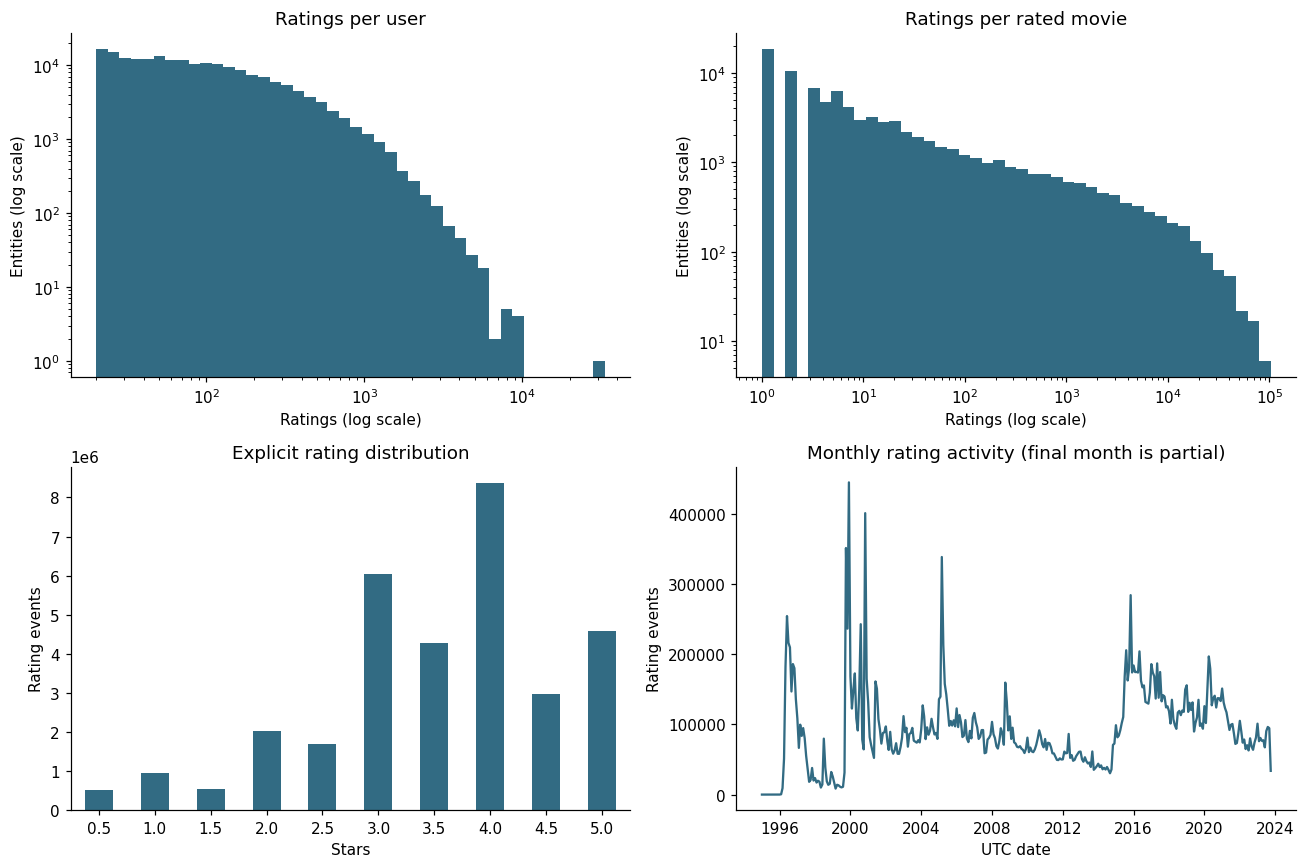

,ratings
1995,4
1996,1571368
1997,685388
1998,301691
1999,1174629
2000,1912322
2001,1160098
2002,849762
2003,1011000
2004,1139068


,observed_user_history_span_days
count,200948.000000
mean,259.117871
std,822.072529
min,0.000000
10%,0.004838
50%,0.065289
90%,708.981725
99%,4434.721153
max,9515.140428


,catalog_movies,rating_events
genre,,
Drama,34175,13973271
Comedy,23124,11206926
Action,9668,9665213
Thriller,11823,8679464
Adventure,5402,7590522
Sci-Fi,4907,5717337
Romance,10369,5524615
Crime,6976,5373051
Fantasy,3851,3702759


In [5]:
activity = pd.DataFrame({
    'ratings_per_user': pd.Series(user_count[active_users]).describe(percentiles=[.01,.1,.25,.5,.75,.9,.95,.99]),
    'ratings_per_rated_movie': pd.Series(item_count[active_items]).describe(percentiles=[.01,.1,.25,.5,.75,.9,.95,.99])})
display(activity)
sorted_popularity = np.sort(item_count[active_items])[::-1]
concentration = []
for fraction in [.01, .05, .10, .20]:
    n = max(1, int(np.ceil(len(active_items) * fraction)))
    concentration.append({'top_rated_movie_fraction': fraction, 'movies': n,
                           'share_of_ratings_pct': 100 * sorted_popularity[:n].sum() / total_ratings})
display(pd.DataFrame(concentration))
display(pd.DataFrame({'minimum_ratings': [1, 5, 10, 20, 50, 100],
                     'users_below_threshold': [int((user_count[active_users] < x).sum()) for x in [1,5,10,20,50,100]],
                     'rated_movies_below_threshold': [int((item_count[active_items] < x).sum()) for x in [1,5,10,20,50,100]]}))
top_movies = movies.assign(ratings=item_count[movies.movieId],
    mean_rating=np.divide(item_rating_sum[movies.movieId], item_count[movies.movieId],
                         out=np.full(len(movies), np.nan), where=item_count[movies.movieId]>0))
display(top_movies.nlargest(15, 'ratings')[['movieId','title','ratings','mean_rating']])
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, values, title in [(axes[0,0], user_count[active_users], 'Ratings per user'),
                          (axes[0,1], item_count[active_items], 'Ratings per rated movie')]:
    ax.hist(values, bins=np.geomspace(max(1, values.min()), values.max()+1, 45), color='#326b83')
    ax.set(xscale='log', yscale='log', title=title, xlabel='Ratings (log scale)', ylabel='Entities (log scale)')
pd.Series(rating_hist).sort_index().plot.bar(ax=axes[1,0], color='#326b83', rot=0)
axes[1,0].set(title='Explicit rating distribution', xlabel='Stars', ylabel='Rating events')
monthly = pd.Series(monthly_hist).sort_index()
monthly.index = pd.to_datetime(monthly.index, utc=True)
axes[1,1].plot(monthly.index, monthly.values, color='#326b83')
axes[1,1].set(title='Monthly rating activity (final month is partial)', xlabel='UTC date', ylabel='Rating events')
fig.tight_layout()
plt.show()
annual = monthly.groupby(monthly.index.year).sum().rename('ratings').to_frame()
display(annual)
user_span_days = (user_last[active_users] - user_first[active_users]) / 86400
display(pd.Series(user_span_days, name='observed_user_history_span_days').describe(percentiles=[.1,.5,.9,.99]).to_frame())
genre_stats = genres.assign(ratings=item_count[genres.movieId]).groupby('genre').agg(
    catalog_movies=('movieId','size'), rating_events=('ratings','sum')).sort_values('rating_events', ascending=False)
display(genre_stats)

## 5. Tags and metadata coverage

Tags provide optional, user-written descriptions of movies. This section checks their completeness, blank text, movie references, user coverage, and duplicate events before considering them as model features. To count duplicates correctly across batches, the scan retains the final user's rows and checks global user ordering. Repeated text from different users is a legitimate separate contribution, so it is not removed as a duplicate event.

Use the coverage percentages to judge whether tags can be a primary feature or need a fallback. Also distinguish **having a tag somewhere in the full release** from **having that tag available at training time**. A tag recorded after the relevant cutoff must not be used to build a historical feature.

In [6]:
tag_quality = Counter()
tag_users, tag_movies = set(), set()
tag_min, tag_max = INF, 0
carry = pd.DataFrame()
last_complete_user = -1
tag_rows = 0

def audit_complete_tag_users(frame):
    global last_complete_user
    if frame.empty:
        return
    assert frame.userId.is_monotonic_increasing, 'Tag users not sorted: global duplicate audit required.'
    assert int(frame.userId.iloc[0]) > last_complete_user
    tag_quality['duplicate_tag_events'] += int(frame.duplicated(['userId','movieId','tag','timestamp']).sum())
    last_complete_user = int(frame.userId.iloc[-1])

for chunk in pd.read_csv(DATA_DIR / 'tags.csv', chunksize=CHUNK_SIZE, keep_default_na=False):
    assert list(chunk.columns) == ['userId','movieId','tag','timestamp']
    for col in ['userId','movieId','timestamp']:
        chunk[col] = pd.to_numeric(chunk[col], errors='raise')
        assert chunk[col].notna().all() and chunk[col].mod(1).eq(0).all()
    assert chunk.userId.gt(0).all() and chunk.movieId.gt(0).all()
    tag_rows += len(chunk)
    tag_quality['missing_cells'] += int(chunk.isna().sum().sum())
    tag_quality['blank_tag_text'] += int(chunk.tag.str.strip().eq('').sum())
    tag_quality['unknown_movie_rows'] += int((~chunk.movieId.isin(movies.movieId)).sum())
    tag_quality['users_without_ratings_rows'] += int((~chunk.userId.isin(active_users)).sum())
    ts = pd.to_datetime(chunk.timestamp, unit='s', utc=True, errors='coerce')
    tag_quality['invalid_timestamps'] += int(ts.isna().sum())
    tag_min = min(tag_min, int(chunk.timestamp.min()))
    tag_max = max(tag_max, int(chunk.timestamp.max()))
    tag_users.update(chunk.userId.unique().tolist())
    tag_movies.update(chunk.movieId.unique().tolist())
    combined = pd.concat([carry, chunk], ignore_index=True)
    assert combined.userId.is_monotonic_increasing
    last_user = combined.userId.iloc[-1]
    audit_complete_tag_users(combined.loc[combined.userId != last_user])
    carry = combined.loc[combined.userId == last_user].copy()
audit_complete_tag_users(carry)
display(pd.Series(tag_quality, name='count').to_frame())
display(pd.Series({'tag_events': tag_rows, 'tagging_users': len(tag_users), 'tagged_movies': len(tag_movies),
                   'catalog_with_tags_pct': 100*len(tag_movies & set(movies.movieId))/len(movies),
                   'rating_users_who_tag_pct': 100*len(tag_users & set(active_users))/len(active_users),
                   'earliest_tag_UTC': str(pd.to_datetime(tag_min, unit='s', utc=True)),
                   'latest_tag_UTC': str(pd.to_datetime(tag_max, unit='s', utc=True))}).to_frame('observed'))
assert tag_rows == 2_000_072, 'Tag count differs from bundled documentation.'
del carry, combined, chunk

,count
missing_cells,0
blank_tag_text,6
unknown_movie_rows,0
users_without_ratings_rows,0
invalid_timestamps,0
duplicate_tag_events,0


,observed
tag_events,2000072
tagging_users,15848
tagged_movies,51323
catalog_with_tags_pct,58.597933
rating_users_who_tag_pct,7.886617
earliest_tag_UTC,2005-12-24 13:00:10+00:00
latest_tag_UTC,2023-10-12 23:56:23+00:00


## 6. Compare global temporal split candidates

A temporal split uses the date of each rating to place it in training, validation, or testing. Training provides the history the model learns from; validation helps choose settings; testing is reserved for the final assessment.

The boundary rules are:

- **Training:** timestamp < validation start.
- **Validation:** validation start <= timestamp < test start.
- **Test:** timestamp >= test start.

All boundaries use UTC, and equal timestamps remain together. This represents a fixed-date experiment: learn from earlier activity and assess performance on later activity.

There are **five alternative splits**, each using the same full dataset. Three use fixed calendar dates. The other two target approximately 80/10/10 and 70/20/10 of the rating records. The ratio-based cutoffs are placed at midnight following the day containing the target cumulative count, so the proportions are approximate. The percentages refer to rating events, not years or users. Calendar windows have different proportions because activity is uneven over time.

**How to read the results:** `warm_rows` means that both the user and movie appear in training. A cold user or movie has no record in that training partition. All cold-start percentages are measured against **training only**, without retraining on validation. The user and movie percentages can overlap, so do not add them to get a total cold-start percentage.

Warm-only evaluation excludes some genuine future interactions, so the retained fraction needs to be reported. Ratings of at least 4 stars are also counted as a possible positive-label definition, but that choice has not been finalized. The assertions check that partition counts reconcile and their timestamps obey the boundary rules.

In [7]:
day_counts = pd.Series(daily_hist).sort_index()
cumulative = day_counts.cumsum().to_numpy()
quantile_dates = {q: str(pd.to_datetime(int(day_counts.index[np.searchsorted(cumulative, total_ratings*q)]) + 1, unit='D', utc=True).date()) for q in [.7,.8,.9]}
scenarios = {
    'calendar_2018_2020': ('2018-01-01', '2020-01-01'),
    'calendar_2020_2022': ('2020-01-01', '2022-01-01'),
    'calendar_2021_2023': ('2021-01-01', '2023-01-01'),
    'approx_80_10_10': (quantile_dates[.8], quantile_dates[.9]),
    'approx_70_20_10': (quantile_dates[.7], quantile_dates[.9]),
}
cutoffs = {name: tuple(int(pd.Timestamp(d, tz='UTC').timestamp()) for d in dates)
           for name, dates in scenarios.items()}
display(pd.DataFrame([{'scenario': k, 'validation_start_UTC': v[0], 'test_start_UTC': v[1]}
                      for k,v in scenarios.items()]))
# Keep per-partition counts for user/movie overlap and training-history checks.
stats = {}
for name in scenarios:
    for part in ['train','validation','test']:
        stats[name,part] = {'rows': 0, 'positive_rows': 0, 'cold_user_rows': 0, 'cold_item_rows': 0,
                           'both_cold_rows': 0, 'warm_rows': 0, 'warm_positive_rows': 0,
                           'minimum_timestamp': INF, 'maximum_timestamp': 0,
                           'users': np.zeros(len(user_count), dtype=np.int32),
                           'items': np.zeros(len(item_count), dtype=np.int32)}
for chunk in pd.read_csv(DATA_DIR / 'ratings.csv', chunksize=CHUNK_SIZE,
                         dtype={'userId':'int32','movieId':'int32','rating':'float32','timestamp':'int64'}):
    u, i, r, t = [chunk[c].to_numpy() for c in rating_columns]
    for name, (validation_start, test_start) in cutoffs.items():
        cold_u = user_first[u] >= validation_start
        cold_i = item_first[i] >= validation_start
        masks = {'train': t < validation_start,
                 'validation': (t >= validation_start) & (t < test_start), 'test': t >= test_start}
        for part, mask in masks.items():
            s = stats[name,part]
            count = int(mask.sum())
            if not count:
                continue
            positive = r[mask] >= 4
            cu, ci = cold_u[mask], cold_i[mask]
            s['rows'] += count
            s['positive_rows'] += int(positive.sum())
            s['cold_user_rows'] += int(cu.sum())
            s['cold_item_rows'] += int(ci.sum())
            s['both_cold_rows'] += int((cu & ci).sum())
            s['warm_rows'] += int((~cu & ~ci).sum())
            s['warm_positive_rows'] += int((positive & ~cu & ~ci).sum())
            s['minimum_timestamp'] = min(s['minimum_timestamp'], int(t[mask].min()))
            s['maximum_timestamp'] = max(s['maximum_timestamp'], int(t[mask].max()))
            np.add.at(s['users'], u[mask], 1)
            np.add.at(s['items'], i[mask], 1)
rows = []
for (name,part), s in stats.items():
    train = stats[name,'train']
    rows.append({'scenario': name, 'partition': part, 'ratings': s['rows'],
                 'dataset_pct': 100*s['rows']/total_ratings,
                 'users': int(np.count_nonzero(s['users'])), 'movies': int(np.count_nonzero(s['items'])),
                 'cold_users': int(((s['users']>0) & (train['users']==0)).sum()),
                 'cold_movies': int(((s['items']>0) & (train['items']==0)).sum()),
                 'cold_user_rows_pct': 100*s['cold_user_rows']/s['rows'],
                 'cold_movie_rows_pct': 100*s['cold_item_rows']/s['rows'],
                 'warm_rows_pct': 100*s['warm_rows']/s['rows'],
                 'positive_rows_pct': 100*s['positive_rows']/s['rows'],
                 'warm_positive_rows': s['warm_positive_rows']})
split_table = pd.DataFrame(rows)
display(split_table.round(2))
for name, (vstart,tstart) in cutoffs.items():
    tr, va, te = [stats[name,p] for p in ['train','validation','test']]
    assert sum(s['rows'] for s in [tr,va,te]) == total_ratings
    assert tr['maximum_timestamp'] < vstart <= va['minimum_timestamp']
    assert va['maximum_timestamp'] < tstart <= te['minimum_timestamp']
    for s in [tr,va,te]:
        assert int(s['users'].sum()) == int(s['items'].sum()) == s['rows']
        assert s['warm_rows'] == s['rows'] - s['cold_user_rows'] - s['cold_item_rows'] + s['both_cold_rows']
print('All candidate partitions reconcile to the source and obey their temporal boundaries.')

,scenario,validation_start_UTC,test_start_UTC
0,calendar_2018_2020,2018-01-01,2020-01-01
1,calendar_2020_2022,2020-01-01,2022-01-01
2,calendar_2021_2023,2021-01-01,2023-01-01
3,approx_80_10_10,2018-10-04,2020-11-06
4,approx_70_20_10,2016-10-14,2020-11-06


,scenario,partition,ratings,dataset_pct,users,movies,cold_users,cold_movies,cold_user_rows_pct,cold_movie_rows_pct,warm_rows_pct,positive_rows_pct,warm_positive_rows
0,calendar_2018_2020,train,24588450,76.84,165667,45548,0,0,0.00,0.00,100.00,49.87,12261828
1,calendar_2018_2020,validation,2776524,8.68,20945,50295,13752,14404,79.38,5.90,17.58,49.81,197625
2,calendar_2018_2020,test,4635230,14.49,29346,70027,24181,33763,87.10,14.51,8.63,49.48,155188
3,calendar_2020_2022,train,27364974,85.51,179419,59952,0,0,0.00,0.00,100.00,49.86,13644889
4,calendar_2020_2022,validation,2928071,9.15,21231,54500,14199,13531,80.23,4.05,17.53,50.51,213950
5,calendar_2020_2022,test,1707159,5.33,14301,51858,9970,16675,82.41,11.97,12.52,47.70,81342
6,calendar_2021_2023,train,29053133,90.79,187950,66750,0,0,0.00,0.00,100.00,49.94,14508994
7,calendar_2021_2023,validation,2153017,6.73,17014,53880,9579,12934,73.89,5.67,22.48,48.40,199989
8,calendar_2021_2023,test,794054,2.48,8847,37117,5010,8452,80.82,10.77,14.07,48.76,44149
9,approx_80_10_10,train,25602867,80.01,170509,50986,0,0,0.00,0.00,100.00,49.84,12760312


All candidate partitions reconcile to the source and obey their temporal boundaries.


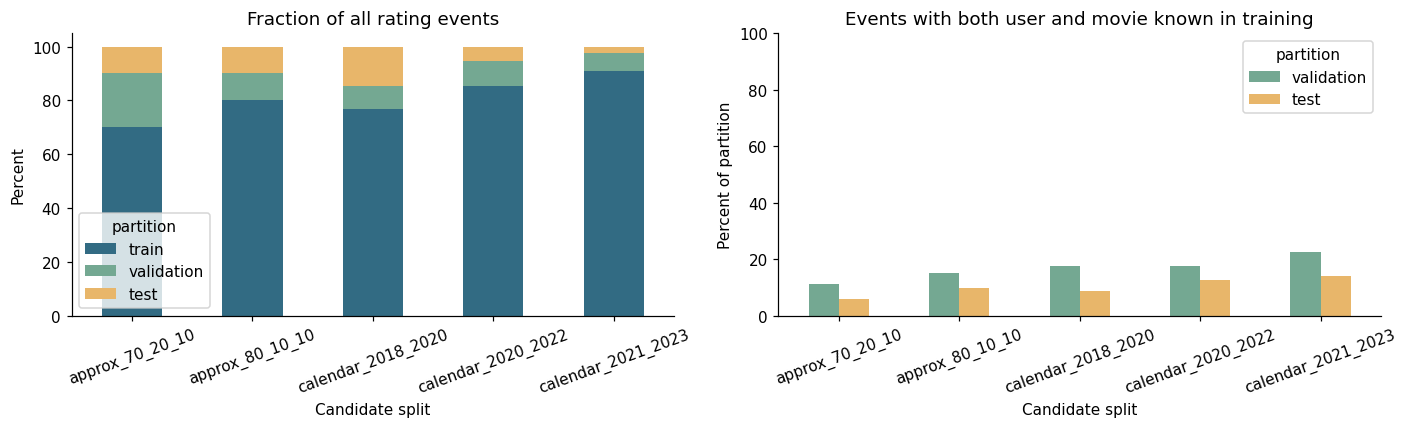

,scenario,partition,minimum_training_ratings,eligible_heldout_users,heldout_events_from_eligible_users_pct
0,calendar_2018_2020,validation,1,7193,20.62
1,calendar_2018_2020,validation,5,7139,20.33
2,calendar_2018_2020,validation,20,6908,19.61
3,calendar_2018_2020,test,1,5165,12.90
4,calendar_2018_2020,test,5,5114,12.80
5,calendar_2018_2020,test,20,4942,12.36
6,calendar_2020_2022,validation,1,7032,19.77
7,calendar_2020_2022,validation,5,6978,19.57
8,calendar_2020_2022,validation,20,6765,18.87
9,calendar_2020_2022,test,1,4331,17.59


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
split_table.pivot(index='scenario',columns='partition',values='dataset_pct')[['train','validation','test']].plot.bar(
    stacked=True, ax=axes[0], color=['#326b83','#74a892','#e8b66a'], rot=20)
axes[0].set(title='Fraction of all rating events', ylabel='Percent', xlabel='Candidate split')
split_table.query("partition != 'train'").pivot(index='scenario',columns='partition',values='warm_rows_pct')[['validation','test']].plot.bar(
    ax=axes[1], color=['#74a892','#e8b66a'], rot=20)
axes[1].set(title='Events with both user and movie known in training', ylabel='Percent of partition', xlabel='Candidate split', ylim=(0,100))
fig.tight_layout()
plt.show()
# Count only training interactions when deciding whether a user has enough history.
history_rows = []
for name in scenarios:
    train_counts = stats[name,'train']['users']
    for part in ['validation','test']:
        heldout_counts = stats[name,part]['users']
        for minimum in [1,5,20]:
            eligible = train_counts >= minimum
            history_rows.append({'scenario':name, 'partition':part, 'minimum_training_ratings':minimum,
                                 'eligible_heldout_users':int(((heldout_counts>0)&eligible).sum()),
                                 'heldout_events_from_eligible_users_pct':100*heldout_counts[eligible].sum()/heldout_counts.sum()})
display(pd.DataFrame(history_rows).round(2))

## 6b. Direct comparison: 70/20/10 versus 80/10/10

For this comparison, the test period stays fixed. Both options use the same 90% boundary and therefore contain identical test events. Changing from 80/10/10 to 70/20/10 moves an earlier block of ratings from training into validation. Read the table as a tradeoff between **more validation data** and **more training history**. Alongside record counts, it shows how many users and movies are available in training and what fraction of later events involve known users and movies. These are coverage measurements, not recommendation-quality scores. A lower warm-start percentage means more test events need a cold-start strategy; it does not, by itself, establish a worse model.

For a later model comparison, I recommend keeping the test events fixed and reporting both full serving coverage and results on a common eligible warm population. That avoids comparing scores calculated on different subsets. The different validation periods can also introduce different time drift. One further detail matters: if both models are refit on **train plus validation** before testing, they will have the same combined historical data. The training-only cold-start figures below would then need to be recalculated for that protocol.

In [9]:
comparison_rows = []
for name in ['approx_80_10_10', 'approx_70_20_10']:
    tr, va, te = [stats[name, part] for part in ['train', 'validation', 'test']]
    comparison_rows.append({
        'split': name.replace('approx_', ''),
        'validation_start_UTC': scenarios[name][0], 'test_start_UTC': scenarios[name][1],
        'train_ratings': tr['rows'], 'validation_ratings': va['rows'], 'test_ratings': te['rows'],
        'training_users': int(np.count_nonzero(tr['users'])),
        'training_movies': int(np.count_nonzero(tr['items'])),
        'median_training_ratings_per_user': float(np.median(tr['users'][tr['users'] > 0])),
        'validation_warm_events_pct': 100*va['warm_rows']/va['rows'],
        'test_warm_events_pct': 100*te['warm_rows']/te['rows'],
        'test_cold_user_events_pct': 100*te['cold_user_rows']/te['rows'],
        'test_cold_movie_events_pct': 100*te['cold_item_rows']/te['rows'],
        'test_warm_positive_events': te['warm_positive_rows']})
ratio_comparison = pd.DataFrame(comparison_rows).set_index('split')
display(ratio_comparison.T)
a, b = 'approx_80_10_10', 'approx_70_20_10'
assert cutoffs[a][1] == cutoffs[b][1]
assert np.array_equal(stats[a,'test']['users'], stats[b,'test']['users'])
assert np.array_equal(stats[a,'test']['items'], stats[b,'test']['items'])
assert stats[a,'test']['rows'] == stats[b,'test']['rows']
assert stats[b,'train']['rows'] < stats[a,'train']['rows']
assert stats[b,'test']['warm_rows'] <= stats[a,'test']['warm_rows']
transferred = stats[a,'train']['rows'] - stats[b,'train']['rows']
assert stats[b,'validation']['rows'] - stats[a,'validation']['rows'] == transferred
loss_pp = 100*(stats[a,'test']['warm_rows']-stats[b,'test']['warm_rows'])/stats[a,'test']['rows']
display(Markdown(f"""### What changed?
- Moving to 70/20/10 transfers **{transferred:,} ratings** from training to validation.
- The test period starts **{scenarios[b][1]}** in both cases, with **{stats[b,'test']['rows']:,} identical events**.
- Warm test coverage is **{100*stats[a,'test']['warm_rows']/stats[a,'test']['rows']:.2f}%** for 80/10/10 and **{100*stats[b,'test']['warm_rows']/stats[b,'test']['rows']:.2f}%** for 70/20/10, a decrease of **{loss_pp:.2f} percentage points**.
- The tradeoff is more validation data with 70/20/10 versus more training history and warm coverage with 80/10/10. This does not yet tell us which produces better recommendations.
"""))

split,80_10_10,70_20_10
validation_start_UTC,2018-10-04,2016-10-14
test_start_UTC,2020-11-06,2020-11-06
train_ratings,25602867,22402130
validation_ratings,3198273,6399010
test_ratings,3199064,3199064
training_users,170509,154619
training_movies,50986,36531
median_training_ratings_per_user,70.0,68.0
validation_warm_events_pct,15.066819,11.236879
test_warm_events_pct,9.792677,5.824954


### What changed?
- Moving to 70/20/10 transfers **3,200,737 ratings** from training to validation.
- The test period starts **2020-11-06** in both cases, with **3,199,064 identical events**.
- Warm test coverage is **9.79%** for 80/10/10 and **5.82%** for 70/20/10, a decrease of **3.97 percentage points**.
- The tradeoff is more validation data with 70/20/10 versus more training history and warm coverage with 80/10/10. This does not yet tell us which produces better recommendations.


## 7. Findings and implications

The summary below brings together the measured results. After that, the notes explain what they mean for preprocessing, split selection, and the next phase of the project.

Keep the descriptive analysis separate from feature construction. Full-release distributions are useful for understanding the dataset, but fitted features and statistics must use only the historical data allowed by the evaluation protocol.

In [10]:
approx = split_table.query("scenario == 'approx_80_10_10'").set_index('partition')
top_one = concentration[0]['share_of_ratings_pct']
display(Markdown(f"""
### Observed
- The full scan covers **{total_ratings:,} ratings**, **{len(active_users):,} rating users**, **{len(active_items):,} rated movies** and **{len(movies):,} catalog movies**.
- All four CSV checksums match the bundled manifest.
- The ratings audit found **{quality['missing_cells']:,} missing cells**, **{quality['invalid_ratings']:,} invalid star values**, **{quality['unknown_movie_rows']:,} missing movie references** and **{quality['adjacent_repeated_user_movie_pairs']:,} repeated user–movie pairs**, with global source ordering verified.
- The median user has **{np.median(user_count[active_users]):,.0f} ratings**; the median rated movie has **{np.median(item_count[active_items]):,.0f} ratings**. The most-rated 1% of rated movies account for **{top_one:.1f}%** of rating events.
- Tags cover **{100*len(tag_movies & set(movies.movieId))/len(movies):.1f}%** of catalog movies, so any tag-based feature needs a plan for missing coverage.
- The approximate 80/10/10 boundaries are **{scenarios['approx_80_10_10'][0]}** and **{scenarios['approx_80_10_10'][1]}**, both at midnight UTC.
- With this candidate, **{approx.loc['validation','warm_rows_pct']:.1f}%** of validation events and **{approx.loc['test','warm_rows_pct']:.1f}%** of test events involve both a user and a movie present in training.
- The documented 20-rating minimum applies to complete histories. It does not guarantee 20 training interactions per user under a historical split.
"""))


### Observed
- The full scan covers **32,000,204 ratings**, **200,948 rating users**, **84,432 rated movies** and **87,585 catalog movies**.
- All four CSV checksums match the bundled manifest.
- The ratings audit found **0 missing cells**, **0 invalid star values**, **0 missing movie references** and **0 repeated user–movie pairs**, with global source ordering verified.
- The median user has **73 ratings**; the median rated movie has **5 ratings**. The most-rated 1% of rated movies account for **54.9%** of rating events.
- Tags cover **58.6%** of catalog movies, so any tag-based feature needs a plan for missing coverage.
- The approximate 80/10/10 boundaries are **2018-10-04** and **2020-11-06**, both at midnight UTC.
- With this candidate, **15.1%** of validation events and **9.8%** of test events involve both a user and a movie present in training.
- The documented 20-rating minimum applies to complete histories. It does not guarantee 20 training interactions per user under a historical split.


### Additional observations that affect preprocessing

- **Six tag events have blank text.** My recommendation is to trim whitespace, treat empty text as missing in the future tag table, and report any removed rows. No tags have been changed here.
- **3,153 catalog movies have no ratings.** Keep these in the catalog, but do not assume they can participate in collaborative training. There are also **7,080 movies without listed genres** and **124 links without TMDb IDs**. Missing metadata should remain explicit rather than cause all related interactions to be discarded.
- **The median recorded user-history span is about 94 minutes**, despite a median of 73 ratings. This is consistent with users entering many ratings in a short session; it does not establish when they watched the movies. It may help explain why many users fall entirely on one side of a global cutoff.
- **The latest rating is 2023-10-13 02:29:07 UTC**, with **108 ratings on October 13 UTC**. The README says activity ends October 12 and the release was generated October 13. A timezone or reporting boundary could explain this, but the cause has not been verified. Preserve these valid timestamps and document the discrepancy rather than automatically deleting the rows.

### Interpretation of the ratio comparison

The 70/20/10 option begins validation on **2016-10-14**, while 80/10/10 begins on **2018-10-04**. Both begin testing on **2020-11-06**. Moving the training cutoff earlier gives us a larger validation set but reduces the training population from **170,509 to 154,619 users** and from **50,986 to 36,531 movies**.

Warm test-event coverage falls from **9.79% to 5.82%**. About **90.0%** of test events in 70/20/10 involve users absent from its training partition. This is the main practical cost of moving more data into validation.

My reading is that **80/10/10 is stronger for training-only warm coverage**, while 70/20/10 offers more validation events and a longer validation period. Neither resolves the cold-start issue. Choosing a model-quality winner still requires controlled experiments, a clearly defined test population, and a decision about refitting on train plus validation.

### Recommended decisions for the next phase

1. **Keep the raw files unchanged.** Use a dedicated raw-data location in the pipeline. The current fallback path is inside the Python source package, so document or relocate it deliberately rather than copying that assumption throughout the code.
2. **Choose the evaluation question before finalizing the split.** For a fixed-date future-serving experiment, use a global cutoff and report warm-start and cold-start performance separately. The 80/10/10 option retains only 15.1% warm validation events and 9.8% warm test events; the calendar options retain between 8.6% and 14.1% warm test events. If the main goal is next-interaction prediction for established users, investigate a per-user chronological protocol. That alternative has not been tested here and needs controls for cross-user future information. Keep equal timestamps together and document the boundary rules.
3. **State who is included in evaluation.** Report total future-event counts and the fraction retained for warm-start scoring. For unseen users or movies, use an explicit fallback or a separate cold-start evaluation instead of silently removing their events. Recalculate coverage if the final model is retrained on train plus validation.
4. **Retain the explicit ratings initially.** A rating of at least 4 stars is a candidate relevance label, not a settled rule. Decide how lower ratings will be used and which candidate items will be ranked before calculating recommendation metrics. An unrated movie is not a known dislike.
5. **Build features from information available at the time.** Fit popularity, user histories, normalization, vocabularies, and learned encoders using the permitted training history. Include tags only when their timestamps precede the relevant cutoff. Document that movie metadata is a release snapshot without historical availability timestamps.
6. **Assess sparsity using training data before filtering.** Any minimum-history rule changes the evaluation population. Report how many users, movies, and events it excludes, and keep original IDs alongside any later integer mappings.
7. **Agree on a shared schema before implementing the pipeline.** My proposed starting point is an interaction table with `user_id`, `movie_id`, `rating`, and `timestamp_utc`; a movie table with `movie_id`, `title`, and `genres`; and optional tag and external-ID tables. Preserve source identifiers and UTC timestamp semantics. This schema is a proposal and has not been implemented or finalized.

### Limitations and questions the data cannot answer

- **The users are not a random sample of all viewers.** This is explicit feedback from self-selected MovieLens users with at least 20 ratings in the full release. It does not describe all viewing activity or all exposures. No demographics are supplied, so demographic fairness claims cannot be supported from these files.
- **The planned propensity-based evaluation needs more data.** There are no recommendation impressions, displayed positions, action-selection probabilities, or outcomes for unshown items. These files alone cannot support the planned logged-propensity IPS/SNIPS/DR experiments. The separate evaluation dataset anticipated by the proposal remains later work.
- **Popularity concentration does not establish model bias.** It describes the source data. Model outputs are needed to assess recommendation concentration and subgroup performance.
- **The time records have limits.** The data end in October 2023, so the final month and year are incomplete. Rating timestamps are not watch timestamps, and one retained user-movie record cannot reconstruct repeated rating updates.
- **Metadata is a snapshot.** Titles and genres are taken from the release, and extracted years are heuristic. External IDs do not provide fetched descriptions, posters, or their usage terms.
- **Dataset terms are separate from software licensing.** Use the bundled README for dataset usage terms and citation requirements. The project's MIT software license does not replace them. The later Data Card should document a formal sourcing and licensing review.
- **This is still a data analysis.** No model has been trained and no ranking quality has been measured. Cold-start rates describe the partitions, not model performance.

### Scope completed here

This EDA covers source integrity, ratings and tag quality, metadata coverage, user and movie activity, popularity concentration, activity over time, and five candidate temporal splits. The source rows remain unchanged, and no final train/validation/test files have been written.

The next step is to settle the evaluation population and split protocol using these findings. Those decisions will guide the working data pipeline, final split artifacts, Data Card, and run instructions.